# 02 - Feature Selection

Feature selection should come after feature engineering. The goal is not to keep the smallest possible number of columns; the goal is to remove columns that are useless, unstable, leaky, or harmful for validation WMAE.

This notebook uses three practical checks:

1. Filter features with too much missing/fallback signal or no variance.
2. Inspect highly correlated numeric features.
3. Fit a tree model on a time-based holdout and rank features by importance.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from dataloader import load_raw, merge_all
from features import build_features
from metrics import wmae
from validation import holdout_split

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
RANDOM_STATE = 42
MAX_TRAIN_ROWS = 150_000

In [2]:
train, test, feature_table, stores, sample_submission = load_raw(PROJECT_ROOT / 'data')
train_merged = merge_all(train, feature_table, stores)
X = build_features(train_merged, encode_categoricals=True)
y = train_merged['Weekly_Sales']
weights = np.where(train_merged['IsHoliday'], 5.0, 1.0)

print(X.shape)
X.head()

(421570, 73)


,Store,Dept,IsHoliday,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Quarter,WeekOfYear,DayOfYear,DaysFromStart,WeekSin,WeekCos,MonthSin,MonthCos,is_super_bowl,is_labor_day,is_thanksgiving,is_christmas,DaysToChristmas,is_pre_christmas,is_december,MarkDown1_missing,MarkDown1_log1p,MarkDown2_missing,MarkDown2_log1p,MarkDown3_missing,MarkDown3_log1p,MarkDown4_missing,MarkDown4_log1p,MarkDown5_missing,MarkDown5_log1p,MarkdownMissingCount,AnyMarkdown,TotalMarkdown,TotalMarkdown_log1p,CPI_missing,Unemployment_missing,TempCold,TempHot,TempMild,TempComfortDistance,TemperatureStoreDeviation,FuelPriceStoreDeviation,FuelPriceHigh,TempFuelInteraction,ComfortDistanceFuelInteraction,sales_lag_52,same_week_history_mean,store_dept_history_mean,dept_week_history_mean,store_week_history_mean,sales_lag_52_missing,same_week_history_mean_missing,store_dept_history_mean_missing,dept_week_history_mean_missing,store_week_history_mean_missing,Type_A,Type_B,Type_C,HolidayName_none,HolidayName_super_bowl,HolidayName_labor_day,HolidayName_thanksgiving,HolidayName_christmas
0,1,1,0,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,2010,2,1,5,36,0,0.568065,0.822984,0.866025,5.000000e-01,0,0,0,0,323,0,0,1,0.0,1,0.0,1,0.0,1,0.0,1,0.0,5,0,0.0,0.0,0,0,0,0,0,12.69,-25.914463,-0.646811,0,108.82132,32.63868,15981.258123,15981.258123,17418.992500,15981.258123,15981.258123,1,1,0,1,1,True,False,False,True,False,False,False,False
1,1,1,1,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,2010,2,1,6,43,7,0.663123,0.748511,0.866025,5.000000e-01,1,0,0,0,316,0,0,1,0.0,1,0.0,1,0.0,1,0.0,1,0.0,5,0,0.0,0.0,0,0,0,0,0,16.49,-29.714463,-0.670811,0,98.12348,42.01652,15981.258123,15981.258123,19041.153636,15981.258123,15981.258123,1,1,0,1,1,True,False,False,False,True,False,False,False
2,1,1,0,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,2010,2,1,7,50,14,0.748511,0.663123,0.866025,5.000000e-01,0,0,0,0,309,0,0,1,0.0,1,0.0,1,0.0,1,0.0,1,0.0,5,0,0.0,0.0,0,0,0,0,0,15.07,-28.294463,-0.704811,0,100.38402,37.88598,15981.258123,15981.258123,23597.702857,15981.258123,15981.258123,1,1,0,1,1,True,False,False,True,False,False,False,False
3,1,1,0,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,2010,2,1,8,57,21,0.822984,0.568065,0.866025,5.000000e-01,0,0,0,0,302,0,0,1,0.0,1,0.0,1,0.0,1,0.0,1,0.0,5,0,0.0,0.0,0,0,0,0,0,8.37,-21.594463,-0.657811,0,119.41943,21.43557,15981.258123,15981.258123,27815.844706,15981.258123,15981.258123,1,1,0,1,1,True,False,False,True,False,False,False,False
4,1,1,0,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,2010,3,1,9,64,28,0.885456,0.464723,1.000000,6.123234e-17,0,0,0,0,295,0,0,1,0.0,1,0.0,1,0.0,1,0.0,1,0.0,5,0,0.0,0.0,0,0,0,0,0,8.50,-21.724463,-0.593811,0,122.06250,22.31250,15981.258123,15981.258123,26588.047500,15981.258123,15981.258123,1,1,0,1,1,True,False,False,True,False,False,False,False


## 1. Basic filters

Constant columns cannot help a model. Columns with almost one unique value usually add noise. We inspect them first instead of relying only on model importance.

In [3]:
nunique = X.nunique(dropna=False).sort_values()
low_variance = nunique[nunique <= 1]
display(low_variance.to_frame('nunique'))

missing_rate = X.isna().mean().sort_values(ascending=False)
display(missing_rate.head(10).to_frame('missing_rate'))

,nunique
Unemployment_missing,1
CPI_missing,1


,missing_rate
Store,0.0
Dept,0.0
IsHoliday,0.0
Size,0.0
Temperature,0.0
Fuel_Price,0.0
MarkDown1,0.0
MarkDown2,0.0
MarkDown3,0.0
MarkDown4,0.0


## 2. Correlation check

Correlation does not mean a feature is bad. Tree models can handle correlated features, but very redundant columns make interpretation harder. We use this as a diagnostic, not an automatic deletion rule.

In [4]:
numeric_X = X.select_dtypes(include=[np.number, bool]).astype(float)
corr = numeric_X.sample(min(len(numeric_X), 80_000), random_state=RANDOM_STATE).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .rename('abs_corr')
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b'})
    .query('abs_corr >= 0.98')
    .sort_values('abs_corr', ascending=False)
)
high_corr_pairs.head(30)

,feature_a,feature_b,abs_corr
1959,MarkDown5_missing,AnyMarkdown,1.000000
1447,is_labor_day,HolidayName_labor_day,1.000000
1538,is_christmas,HolidayName_christmas,1.000000
1493,is_thanksgiving,HolidayName_thanksgiving,1.000000
1400,is_super_bowl,HolidayName_super_bowl,1.000000
202,IsHoliday,HolidayName_none,1.000000
1063,DayOfYear,DaysToChristmas,0.999990
1000,WeekOfYear,DayOfYear,0.999969
1010,WeekOfYear,DaysToChristmas,0.999928
2332,sales_lag_52,same_week_history_mean,0.997424


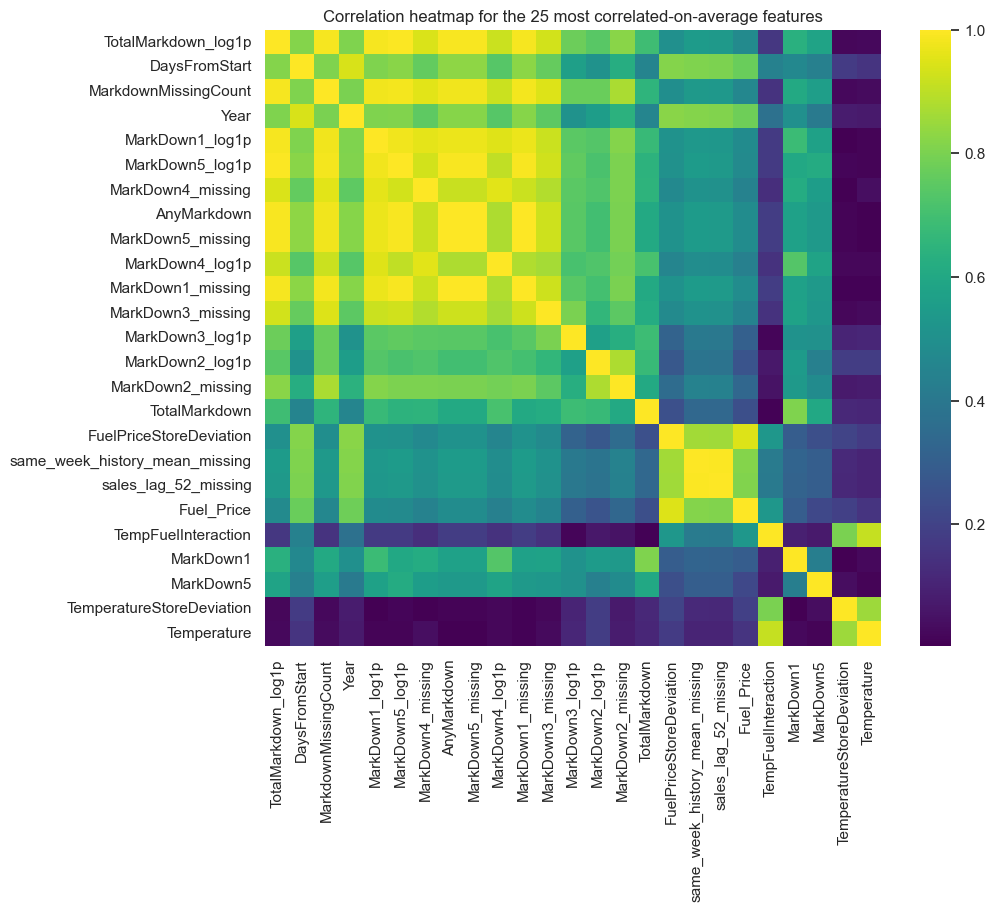

In [5]:
plt.figure(figsize=(10, 8))
top_corr_features = corr.mean().sort_values(ascending=False).head(25).index
sns.heatmap(corr.loc[top_corr_features, top_corr_features], cmap='viridis', square=True)
plt.title('Correlation heatmap for the 25 most correlated-on-average features')
plt.show()

## 3. Time-based holdout and model importance

We split by date, not by random rows. The last 39 weeks become validation, matching the real Kaggle horizon. Holiday rows get weight 5 during training because WMAE also weights them 5.

LightGBM is preferred here because it is fast and usually strong for tabular time-series features. If LightGBM is not installed, the notebook falls back to scikit-learn RandomForest on a sample.

In [6]:
train_mask, val_mask = holdout_split(train_merged['Date'], horizon=39)
train_idx_all = X.index[train_mask]
if len(train_idx_all) > MAX_TRAIN_ROWS:
    train_idx = pd.Series(train_idx_all).sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE).to_numpy()
else:
    train_idx = train_idx_all
val_idx = X.index[val_mask]

def make_model():
    try:
        from lightgbm import LGBMRegressor
        return LGBMRegressor(
            objective='l1',
            n_estimators=600,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    except Exception:
        from sklearn.ensemble import RandomForestRegressor
        return RandomForestRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

def fit_score(feature_names):
    model = make_model()
    model.fit(
        X.loc[train_idx, feature_names],
        y.loc[train_idx],
        sample_weight=weights[train_idx],
    )
    pred = np.clip(model.predict(X.loc[val_idx, feature_names]), 0, None)
    score = wmae(y.loc[val_idx], pred, train_merged.loc[val_idx, 'IsHoliday'])
    return model, score

all_features = [c for c in X.columns if c not in low_variance.index]
model, full_score = fit_score(all_features)
print(f'Full feature holdout WMAE: {full_score:,.2f}')

Full feature holdout WMAE: 1,720.25


,feature,importance
1,Dept,5370
56,dept_week_history_mean,5069
55,store_dept_history_mean,4930
53,sales_lag_52,4183
57,store_week_history_mean,3442
0,Store,1086
3,Size,963
7,MarkDown2,873
12,Unemployment,866
11,CPI,800


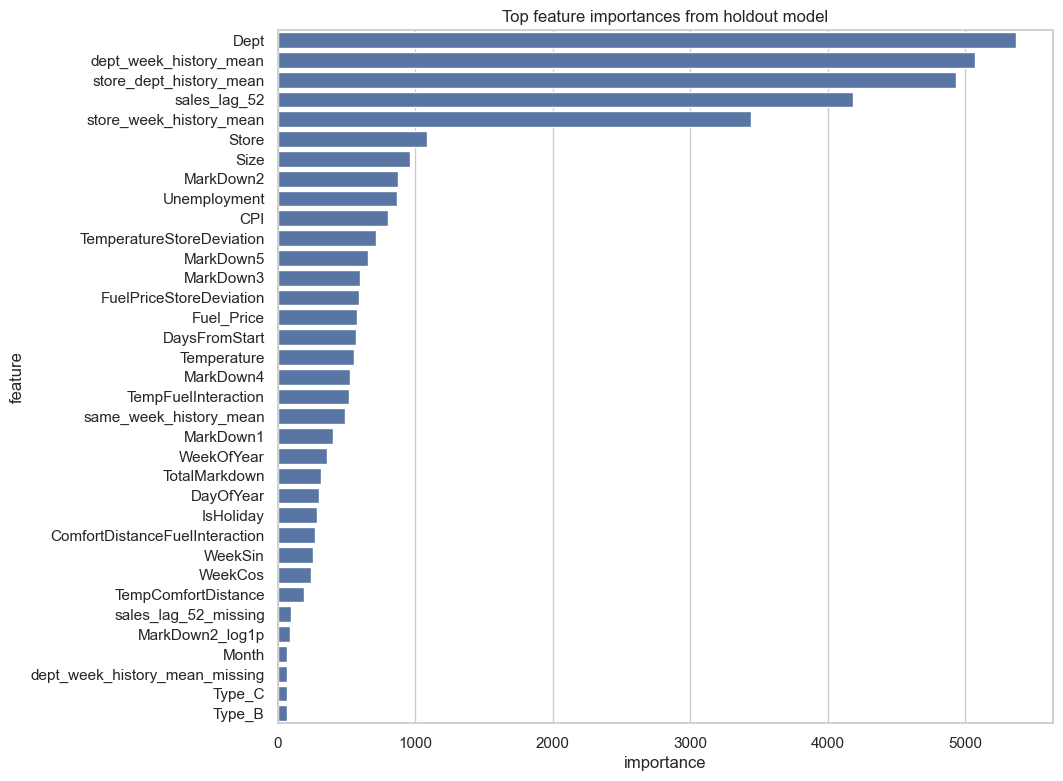

In [7]:
if hasattr(model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': all_features,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)
else:
    raise RuntimeError('The fallback model should still expose feature_importances_.')

display(importance.head(40))

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=importance.head(35), y='feature', x='importance', ax=ax)
ax.set_title('Top feature importances from holdout model')
plt.show()

## Compare selected feature sets

Feature importance is only a ranking. The real test is validation WMAE. We compare the full feature set with top-k subsets. If the subset has the same or better WMAE, it is a cleaner candidate for the model notebooks.

In [8]:
results = []
for k in [15, 25, 35, 50, len(all_features)]:
    selected = importance.head(min(k, len(importance)))['feature'].tolist()
    _, score = fit_score(selected)
    results.append({'feature_count': len(selected), 'holdout_wmae': score})

selection_results = pd.DataFrame(results).sort_values('holdout_wmae')
selection_results

,feature_count,holdout_wmae
4,71,1707.403782
0,15,1708.006756
3,50,1711.774943
2,35,1726.387075
1,25,1729.482003


In [9]:
best_k = int(selection_results.iloc[0]['feature_count'])
selected_features = importance.head(best_k)['feature'].tolist()

print(f'Best tested feature count: {best_k}')
print(selected_features)

Best tested feature count: 71
['Dept', 'dept_week_history_mean', 'store_dept_history_mean', 'sales_lag_52', 'store_week_history_mean', 'Store', 'Size', 'MarkDown2', 'Unemployment', 'CPI', 'TemperatureStoreDeviation', 'MarkDown5', 'MarkDown3', 'FuelPriceStoreDeviation', 'Fuel_Price', 'DaysFromStart', 'Temperature', 'MarkDown4', 'TempFuelInteraction', 'same_week_history_mean', 'MarkDown1', 'WeekOfYear', 'TotalMarkdown', 'DayOfYear', 'IsHoliday', 'ComfortDistanceFuelInteraction', 'WeekSin', 'WeekCos', 'TempComfortDistance', 'sales_lag_52_missing', 'MarkDown2_log1p', 'Month', 'dept_week_history_mean_missing', 'Type_C', 'Type_B', 'is_thanksgiving', 'store_dept_history_mean_missing', 'is_super_bowl', 'DaysToChristmas', 'is_labor_day', 'MarkDown5_log1p', 'MarkDown4_log1p', 'store_week_history_mean_missing', 'MarkDown3_log1p', 'Type_A', 'Year', 'TotalMarkdown_log1p', 'MarkDown1_log1p', 'MonthCos', 'MonthSin', 'is_pre_christmas', 'same_week_history_mean_missing', 'HolidayName_none', 'HolidayNam